# Reward Shaping Experiments

Explore different reward shaping strategies

In [1]:
import sys
import os

# Determine the project root dynamically
def get_project_root():
    current_dir = os.getcwd()
    
    # Check if we're in the notebooks directory
    if os.path.basename(current_dir) == 'notebooks':
        return os.path.dirname(current_dir)
    
    return current_dir

# Add project root to Python path
project_root = get_project_root()
sys.path.insert(0, project_root)

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from src.environment import ScarseGridEnv
from src.agents import MultiAgentQLearning
from src.game_theory import RewardShapingStrategy


Using device: cuda


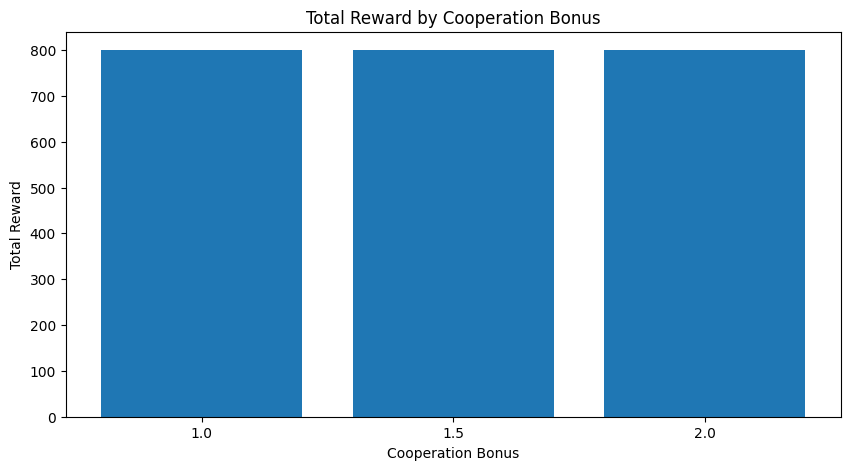

Config: {'cooperation_bonus': 1.0}, Total Reward: 800.0
Config: {'cooperation_bonus': 1.5}, Total Reward: 800.0
Config: {'cooperation_bonus': 2.0}, Total Reward: 800.0


In [4]:
# Reward Shaping Experiment
def run_reward_shaping_experiment(reward_configs):
    results = []
    
    for config in reward_configs:
        # Create environment
        env = ScarseGridEnv()
        
        # Create reward shaper
        reward_shaper = RewardShapingStrategy(config)
        
        # Create multi-agent trainer
        multi_agent_trainer = MultiAgentQLearning(env)
        
        # Train agents
        agent_rewards = multi_agent_trainer.train(num_episodes=50)
        
        # Compute total reward
        total_reward = np.sum(agent_rewards[0] + agent_rewards[1])
        
        results.append({
            'config': config,
            'total_reward': total_reward
        })
    
    return results

# Different reward configuration experiments
reward_configs = [
    {'cooperation_bonus': 1.0},
    {'cooperation_bonus': 1.5},
    {'cooperation_bonus': 2.0}
]

# Run experiment
experiment_results = run_reward_shaping_experiment(reward_configs)

# Visualize Results
plt.figure(figsize=(10, 5))
plt.bar(
    [str(config['cooperation_bonus']) for config in reward_configs],
    [result['total_reward'] for result in experiment_results]
)
plt.title('Total Reward by Cooperation Bonus')
plt.xlabel('Cooperation Bonus')
plt.ylabel('Total Reward')
plt.show()

# Print detailed results
for result in experiment_results:
    print(f"Config: {result['config']}, Total Reward: {result['total_reward']}")
